# Input Testing


FLOOD INFERENCE ENGINE READY
  Device         : cpu
  Model          : ViT
  Spatial patches: 6,480 (Manila mask)
  Patch shape    : (4, 4, 3)
  Rain range     : [0.0000, 189.8531]
  Num classes    : 5
  Batch size     : 256
  Manila indices : 6,480 patches indexed


[run_inference] Starting: triangular_77mm_tp09
Predicting 6,480 patches (batch_size=256)...
  checkmark 1,280/6,480 patches
  checkmark 2,560/6,480 patches
  checkmark 3,840/6,480 patches
  checkmark 5,120/6,480 patches
  checkmark 6,400/6,480 patches
  checkmark 6,480/6,480 patches

PREDICTION SUMMARY
  Storm type     : triangular
  Depth          : 77.0 mm
  tpeak          : 0.9
  No warnings    : inputs within training range

  Confidence stats (Manila patches):
    Mean      : 0.2184
    Std       : 0.0011
    Min       : 0.2132
    Max       : 0.2249
    Uncertain : 100.0%  (conf < 0.5)

  Flood class distribution (Manila patches):
    No Flood    :     186 patches    2.9%  #
    Light       :       0 patches    0.0%

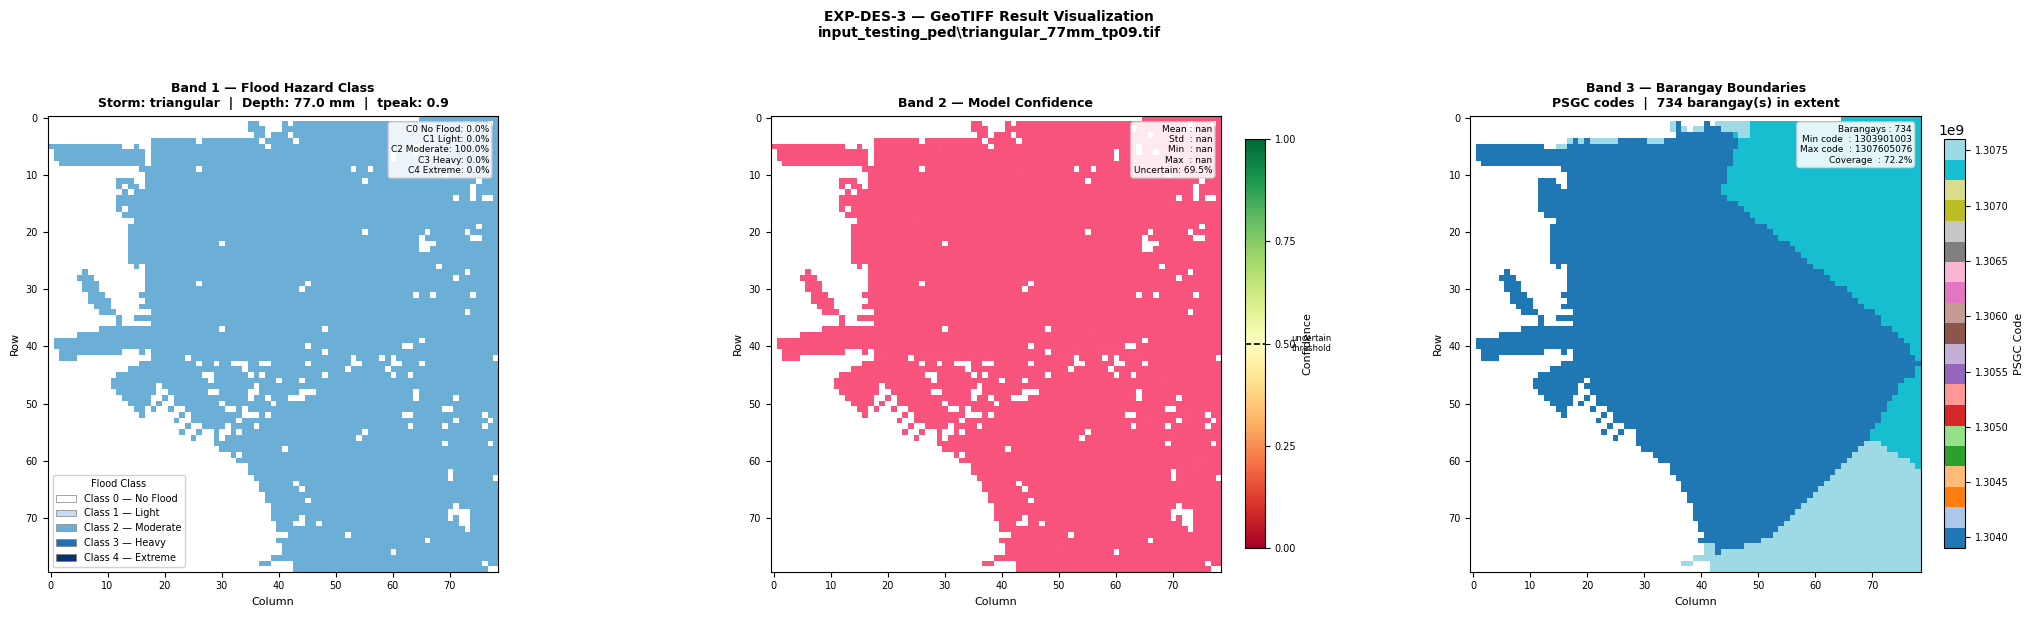

✓ Results saved to input_testing_ped


In [1]:
import numpy as np, torch, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, matplotlib.colors as mcolors
import rasterio
from rasterio.transform import Affine
from pathlib import Path
import os

from config import TrainConfig, ModelConfig
from model_config import make_model
from inference import FloodInferenceEngine
from inference import run_inference

cfg  = TrainConfig()
mcfg = ModelConfig()
PATCH_SIZE = mcfg.patch_size

# ── Spatial data ──────────────────────────────────────────────────────────────
data                 = np.load(cfg.output_ped_dir / 'spatial_data.npz')
X_full               = data['spatial']
manila_patch_indices = data['manila_patch_indices']
rain_min, rain_max   = float(data['rain_min'].item()), float(data['rain_max'].item())
N_H, N_W             = int(data['n_h'].item()),        int(data['n_w'].item())

# ── GeoTIFF transform ────────────────────────────────────────────────────────
with rasterio.open('COP-30m-GMM/greater_mm_bbox_dem_cop.tif') as src:
    t = src.transform
    dem_crs = src.crs
dem_transform = Affine(t.a * PATCH_SIZE, 0, t.c, 0, t.e * PATCH_SIZE, t.f)

# ── Model ─────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = make_model(ModelConfig()).to(device)

ckpt_files = sorted(cfg.output_ped_dir.glob('fold_*/best_model.pt'))
best_ckpt = max(ckpt_files, key=lambda f: torch.load(f, map_location='cpu', weights_only=False).get('best_monitor', -np.inf))

ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# ── Inference engine ──────────────────────────────────────────────────────────
engine = FloodInferenceEngine(
    model       = model,
    device      = device,
    rain_min    = rain_min,
    rain_max    = rain_max,
    X_spatial   = X_full,
    num_classes = cfg.num_classes,
    batch_size  = cfg.batch_size,
    manila_patch_indices = manila_patch_indices, 
)
engine.dem_transform = dem_transform
engine.dem_crs       = dem_crs

repo_root = os.getcwd()
mask_tif_path = os.path.join(repo_root, "manila_box_shape.tif")

result = run_inference(
    engine       = engine,
    storm_type   = 'triangular', # Can also be 'front-loaded', 'back-loaded', 'triangular'
    depth_mm     = 77.0,
    tpeak        = 0.9,          
    output_dir   = Path('./input_testing_ped'),
    N_H          = N_H,
    N_W          = N_W,
    has_barangay = True,
    geojson_path = 'manila_barangay_geojson.geojson',
    mask_tif_path = mask_tif_path 
)